In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random
import os

In [2]:
def gerar_dataframe_vendas_n3(n=150):

    clientes = ["Ana", "Bruno", "Carlos", "Daniela", "Eduardo", "Fernanda", "Gabriel", "Helena"]
    produtos = ["Mouse", "Teclado", "Monitor", "Headset", "Webcam", "Notebook"]

    cidades = ["São Paulo", "Rio", "Curitiba", "Belo Horizonte", "Salvador"]

    datas = pd.date_range(start="2023-01-01", periods=180).tolist()

    dados = {
        "cliente": [random.choice(clientes) for _ in range(n)],
        "produto": [random.choice(produtos) for _ in range(n)],
        "cidade": [random.choice(cidades) for _ in range(n)],
        "quantidade": [random.choice([1, 2, 3, 4, 5, None]) for _ in range(n)],
        "preco_unitario": [random.choice([100, 200, 300, 500, 1000, None]) for _ in range(n)],
        "data_venda": [random.choice(datas) for _ in range(n)]
    }

    df = pd.DataFrame(dados)

    # Introduzindo problemas reais
    df.loc[df.sample(frac=0.1).index, "cidade"] = None
    df.loc[df.sample(frac=0.1).index, "produto"] = None

    return df

In [3]:
def real_format(dados):
    return f"R${dados:,.2f}".replace(",", "-").replace(".", ",").replace("-", ".")

# Coletando dados

In [4]:
df = None
if os.path.exists("dataframe_nivel_3.csv"):
    df = pd.read_csv("dataframe_nivel_3.csv", sep=",")
else:
    df = gerar_dataframe_vendas_n3()
    df.to_csv("dataframe_nivel_3.csv", sep=",", index=False)

# Informações basicas da tabela

In [5]:
df.head()

,cliente,produto,cidade,quantidade,preco_unitario,data_venda
0,Daniela,Headset,Curitiba,3.0,1000.0,2023-05-14
1,Gabriel,Teclado,São Paulo,3.0,NaN,2023-05-19
2,Carlos,Notebook,Curitiba,5.0,NaN,2023-01-08
3,Carlos,Monitor,Curitiba,2.0,500.0,2023-01-04
4,Helena,Notebook,Rio,4.0,500.0,2023-04-07


In [6]:
df.describe()

,quantidade,preco_unitario
count,123.000000,125.000000
mean,2.772358,431.200000
std,1.481100,323.891659
min,1.000000,100.000000
25%,1.000000,200.000000
50%,3.000000,300.000000
75%,4.000000,500.000000
max,5.000000,1000.000000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   cliente         150 non-null    str    
 1   produto         135 non-null    str    
 2   cidade          135 non-null    str    
 3   quantidade      123 non-null    float64
 4   preco_unitario  125 non-null    float64
 5   data_venda      150 non-null    str    
dtypes: float64(2), str(4)
memory usage: 7.2 KB


 Aqui podemos ver que a tabela possuem valores nulos nas colunas: *produto, cidade, quantidade e preco_unitario.*
 Alem disso, a coluna *data_venda* não esta do tipo *datetime*.

# Análise e limpeza

## parte 2 - Exploração e limpeza

### Verificando valores nulos

In [8]:
df_nulo_any = df.isnull().any() # Verifica quais colunas tem valores nulos

df_nulo = df.isnull().sum() # Conta os valores nulos de cada coluna

print(df_nulo_any.head(10))
print("\n")
print(df_nulo)


cliente           False
produto            True
cidade             True
quantidade         True
preco_unitario     True
data_venda        False
dtype: bool


cliente            0
produto           15
cidade            15
quantidade        27
preco_unitario    25
data_venda         0
dtype: int64


### Limpando produtos e cidades nulas

In [9]:
df_limpando = df.dropna(subset=["produto", "cidade"])
df_limpando.isnull().sum().head(10)

cliente            0
produto            0
cidade             0
quantidade        21
preco_unitario    20
data_venda         0
dtype: int64

### Limpando quantidade e precos nulos

In [10]:
df_limpando[["quantidade", "preco_unitario"]].dtypes
# tudo ja esta float então da pra preencher e calcular de boas!

quantidade        float64
preco_unitario    float64
dtype: object

In [11]:
quantidade_mediana = df_limpando["quantidade"].median()
df_limpando.loc[:,"quantidade"] = df_limpando["quantidade"].fillna(quantidade_mediana)
# Quando eu tentei sem .loc deu um aviso. Basicamente: Eu teria que fazer um .copy() na linha de cima.


In [12]:
preco_unit_media = df_limpando["preco_unitario"].mean()
df_limpando.loc[:, "preco_unitario"] = df_limpando["preco_unitario"].fillna(preco_unit_media)

In [13]:
df_limpo = df_limpando.copy()
df_limpo.isnull().sum().head(10)

cliente           0
produto           0
cidade            0
quantidade        0
preco_unitario    0
data_venda        0
dtype: int64

## Parte 2 - Engenharia de dados

### Criando coluna de valor total

In [14]:
df_limpo["valor_total"] = df_limpo["quantidade"] * df_limpo["preco_unitario"]
df_limpo.head()

,cliente,produto,cidade,quantidade,preco_unitario,data_venda,valor_total
0,Daniela,Headset,Curitiba,3.0,1000.0,2023-05-14,3000.0
1,Gabriel,Teclado,São Paulo,3.0,410.0,2023-05-19,1230.0
2,Carlos,Notebook,Curitiba,5.0,410.0,2023-01-08,2050.0
3,Carlos,Monitor,Curitiba,2.0,500.0,2023-01-04,1000.0
4,Helena,Notebook,Rio,4.0,500.0,2023-04-07,2000.0


### Transformando coluna de data_venda para datetime

In [15]:
df_limpo["data_venda"] = pd.to_datetime(df_limpo["data_venda"])
df_limpo.info()

<class 'pandas.DataFrame'>
Index: 120 entries, 0 to 149
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   cliente         120 non-null    str           
 1   produto         120 non-null    str           
 2   cidade          120 non-null    str           
 3   quantidade      120 non-null    float64       
 4   preco_unitario  120 non-null    float64       
 5   data_venda      120 non-null    datetime64[us]
 6   valor_total     120 non-null    float64       
dtypes: datetime64[us](1), float64(3), str(3)
memory usage: 7.5 KB


### Criando a coluna do mes

In [16]:
df_limpo["mes"] = df_limpo["data_venda"].dt.month
df_limpo.head()

,cliente,produto,cidade,quantidade,preco_unitario,data_venda,valor_total,mes
0,Daniela,Headset,Curitiba,3.0,1000.0,2023-05-14,3000.0,5
1,Gabriel,Teclado,São Paulo,3.0,410.0,2023-05-19,1230.0,5
2,Carlos,Notebook,Curitiba,5.0,410.0,2023-01-08,2050.0,1
3,Carlos,Monitor,Curitiba,2.0,500.0,2023-01-04,1000.0,1
4,Helena,Notebook,Rio,4.0,500.0,2023-04-07,2000.0,4


### Criando a coluna com nome do dia da semana

In [17]:
df_limpo["dia_semana"] = df_limpo["data_venda"].dt.day_name()
df_limpo.head()


,cliente,produto,cidade,quantidade,preco_unitario,data_venda,valor_total,mes,dia_semana
0,Daniela,Headset,Curitiba,3.0,1000.0,2023-05-14,3000.0,5,Sunday
1,Gabriel,Teclado,São Paulo,3.0,410.0,2023-05-19,1230.0,5,Friday
2,Carlos,Notebook,Curitiba,5.0,410.0,2023-01-08,2050.0,1,Sunday
3,Carlos,Monitor,Curitiba,2.0,500.0,2023-01-04,1000.0,1,Wednesday
4,Helena,Notebook,Rio,4.0,500.0,2023-04-07,2000.0,4,Friday


## Parte 3 - Análises

In [18]:
df_full = df_limpo.copy()

### Faturamento total por mês

In [21]:
df_fat_por_mes = df_full.groupby("mes")["valor_total"].sum()
df_fat_por_mes.map(real_format).head(12)

mes
1    R$16.780,00
2    R$36.430,00
3    R$30.710,00
4    R$22.520,00
5    R$24.150,00
6    R$14.060,00
Name: valor_total, dtype: str

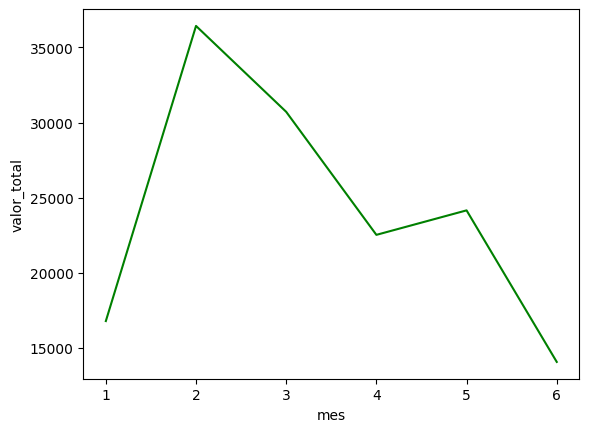

In [37]:
graf_fat_por_mes = df_fat_por_mes.reset_index()
sns.lineplot(x=graf_fat_por_mes["mes"], y=graf_fat_por_mes["valor_total"], markers="o", color="green")
plt.show()

### Melhor mês de vendas

In [20]:
df_melhor_mes_por_vendas = df_full["mes"].value_counts()
print(f"Mês com mais vendas: {df_melhor_mes_por_vendas.idxmax()}")
print(f"Número de vendas: {df_melhor_mes_por_vendas.max()}")


Mês com mais vendas: 3
Número de vendas: 27


In [21]:
df_melhor_mes_por_quant = df_full.groupby("mes")["quantidade"].sum()
print(f"Mês com mais vendas por quantidade: {df_melhor_mes_por_quant.idxmax()}")
print(f"Número de vendas por quantidade: {df_melhor_mes_por_quant.max()}")

Mês com mais vendas por quantidade: 3
Número de vendas por quantidade: 81.0


In [22]:
df_melhor_mes_por_fat = df_full.groupby("mes")["valor_total"].sum()
print(f"Mês com melhor faturamento: {df_melhor_mes_por_fat.idxmax()}")
print(f"Faturamento do mês: {real_format(df_melhor_mes_por_fat.max())}")

Mês com melhor faturamento: 2
Faturamento do mês: R$36.430,00


### Faturamento por dia da semana

In [75]:
df_fat_por_dia = df_full.groupby("dia_semana")["valor_total"].sum()
df_fat_por_dia.map(real_format).head(7)

dia_semana
Friday       R$15.980,00
Monday       R$20.560,00
Saturday     R$26.480,00
Sunday       R$20.740,00
Thursday     R$14.050,00
Tuesday      R$15.040,00
Wednesday    R$31.800,00
Name: valor_total, dtype: object

### Produto mais vendido no geral

In [ ]:
df_prod_mais_venda = df_full["produto"].value_counts()
print(f"Produto com mais vendas: {df_prod_mais_venda.idxmax()}")
print(f"Número de vendas: {df_prod_mais_venda.max()}")

Produto com mais vendas: Teclado
Número de vendas: 26


produto
Teclado     26
Notebook    23
Headset     19
Monitor     19
Mouse       17
Webcam      16
Name: count, dtype: int64

In [82]:
df_prod_mais_venda_quant = df_full.groupby("produto")["quantidade"].sum()
print(f"Produto com mais vendas por quantidade: {df_prod_mais_venda_quant.idxmax()}")
print(f"Número de vendas por quantidade: {df_prod_mais_venda_quant.max()}")


Produto com mais vendas por quantidade: Teclado
Número de vendas por quantidade: 73.0


## Parte 4 - Análise mais "real"

### Qual produto vende mais em cada mês

In [ ]:
df_prod_do_mes = df_full.groupby(["mes", "produto"])["quantidade"].sum().sort_values(ascending=False)
df_prod_do_mes.groupby("mes").head(1)

mes  produto
3    Teclado    25.0
2    Teclado    23.0
5    Headset    16.0
1    Headset    15.0
4    Monitor    10.0
6    Headset     8.0
Name: quantidade, dtype: float64

### Qual cidade gera mais faturamendo em cada mês 

In [91]:
df_cid_do_mes_fat = df_full.groupby(["mes", "cidade"])["valor_total"].sum().sort_values(ascending=False)
df_cid_do_mes_fat.map(real_format).groupby("mes").head(1)

mes  cidade        
2    São Paulo         R$15.320,00
4    Belo Horizonte    R$11.910,00
3    Rio                R$9.600,00
5    Salvador           R$6.700,00
1    Curitiba           R$5.850,00
6    Belo Horizonte     R$3.900,00
Name: valor_total, dtype: object

## Desafio Final

### Qual cliente compra mais em cada cidade

#### Por quantidade:

In [93]:
df_desafio_quant = df_full.groupby(["cidade", "cliente"])["quantidade"].sum().sort_values(ascending=False)
df_desafio_quant.groupby("cidade").head(1)

cidade          cliente
Belo Horizonte  Carlos     22.0
Curitiba        Carlos     20.0
Salvador        Eduardo    15.0
Rio             Gabriel    14.0
São Paulo       Helena     13.0
Name: quantidade, dtype: float64

#### Por valor total de venda:

In [94]:
df_desafio_fat = df_full.groupby(["cidade", "cliente"])["valor_total"].sum().sort_values(ascending=False)
df_desafio_fat.map(real_format).groupby("cidade").head(1)

cidade          cliente
Salvador        Eduardo    R$11.730,00
São Paulo       Helena     R$10.640,00
Curitiba        Carlos      R$7.630,00
Rio             Daniela     R$7.600,00
Belo Horizonte  Bruno       R$7.500,00
Name: valor_total, dtype: object

## Extra - reordenando e salvando o Dataframe

#### Reorganizando as colunas (a gosto)

In [26]:
df_reorganizado = df_full[
    ["cliente", "cidade", "produto", "quantidade", "preco_unitario", "valor_total", "data_venda", "mes", "dia_semana"]
    ]
df_reorganizado.head()

,cliente,cidade,produto,quantidade,preco_unitario,valor_total,data_venda,mes,dia_semana
0,Daniela,Curitiba,Headset,3.0,1000.0,3000.0,2023-05-14,5,Sunday
1,Gabriel,São Paulo,Teclado,3.0,410.0,1230.0,2023-05-19,5,Friday
2,Carlos,Curitiba,Notebook,5.0,410.0,2050.0,2023-01-08,1,Sunday
3,Carlos,Curitiba,Monitor,2.0,500.0,1000.0,2023-01-04,1,Wednesday
4,Helena,Rio,Notebook,4.0,500.0,2000.0,2023-04-07,4,Friday


#### Salvando em um novo csv

In [27]:
df_reorganizado.to_csv("dataframe_nivel_3_completo.csv", sep=",", index=False)